In [3]:
import os
# os.chdir('../../..')
print(os.getcwd())
from fairis_lib.simulation_lib.environment import *
import matplotlib.pyplot as plt
from scipy.stats import levene, normaltest, ttest_ind, wilcoxon
import numpy as np
import pandas as pd
# import seaborn as sns
import csv
from fairis_tools.experiment_tools.loggers.experiment_logger import EpisodeLogger, ExperimentLogger, ShortestPath
import pickle
import math

/Users/titonka/FAIRIS


In [4]:
maze_files = ['WM00_paths.pkl','WM10_paths.pkl','WM20_paths.pkl']
mazes = []
for maze_file in maze_files:
    with open('simulation/worlds/mazes/Experiment1/Paths/'+maze_file,'rb') as file:
        mazes.append(pickle.load(file))
def load_episodes_from_csv(filename):
    episodes = []
    with open(filename, 'r') as file:
        reader = csv.reader(file)
        current_episode = []
        
        for row in reader:
            if not row:  # Blank line signifies a new episode
                if current_episode:
                    episodes.append(current_episode)
                    current_episode = []
                continue
            
            # Convert row to a tuple of floats and add to the current episode
            current_episode.append(list(map(float, row)))
        
        if current_episode:  # Add the last episode if it exists
            episodes.append(current_episode)

    return episodes

def log_optimality_ratio(exp_data):
    maze_names = ['WM00','WM10','WM20']
    path_data = []
    name_index = 0
    for maze in mazes:
        starting_points = []
        path_lengths = []
        for path in maze.paths:
            starting_points.append(path.path[0])
            path_lengths.append(len(path.path)-1)
        path_data.append(ShortestPath(maze_names[name_index],starting_points,path_lengths))
        name_index += 1
    
    path_metrics = {
        'WM00': path_data[0],
        'WM10': path_data[1],
        'WM20': path_data[2]
    }
    for experiment in exp_data:
        maze_ver = experiment.maze_file
        if maze_ver == 'WM00':
            data_index = 0
        elif maze_ver == 'WM10':
            data_index = 1
        shortest_path = path_metrics.get(maze_ver)
        for episode in experiment.episodes:
            start = (episode.path_xs[0] , episode.path_ys[0])
            min_dist = 100
            for s in shortest_path.starting_points:
                dist = math.sqrt((start[0] - s[0])**2 + (start[1]-s[1])**2)
                if dist < min_dist:
                    min_dist = dist
                    eps_start = s  
            min_length = int(shortest_path.path_lengths.get(eps_start))        
            optimality_ratio = (episode.path_length - min_length)/min_length
            experiment.log_optimality_ratio_of_paths(optimality_ratio)
            
maze_names = ['WM00','WM10','WM20']
path_data = []
name_index = 0
for maze in mazes:
    starting_points = []
    path_lengths = []
    for path in maze.paths:
        starting_points.append(path.path[0])
        path_lengths.append(len(path.path)-1)
    path_data.append(ShortestPath(maze_names[name_index],starting_points,path_lengths))
    name_index += 1

path_metrics = {
    'WM00': path_data[0],
    'WM10': path_data[1],
    'WM20': path_data[2]
}

ModuleNotFoundError: No module named 'ExperimentTools'

In [3]:
experiment_data_WM00_PC = []
experiment_data_WM10_PC = []
with open('logs/LargeScale/AllPPOTrainData_WM00_uniform_25_NM','rb') as file:
    temp = pickle.load(file)
    for experiment in temp:
        experiment_data_WM00_PC.append(ExperimentLogger(old_data=experiment))

with open('logs/LargeScale/AllPPOTrainData_WM10_uniform_25_NM','rb') as file:
    temp = pickle.load(file)
    for experiment in temp:
        experiment_data_WM10_PC.append(ExperimentLogger(old_data=experiment))

log_optimality_ratio(experiment_data_WM00_PC)
log_optimality_ratio(experiment_data_WM10_PC)

experiment_data_WM00_no_pc = []
experiment_data_WM10_no_pc =[]
        
with open('logs/LargeScale/AllPPOTrainData_WM00_no_pc','rb') as file:
    temp = pickle.load(file)
    for experiment in temp:
        experiment_data_WM00_no_pc.append(ExperimentLogger(old_data=experiment))
        
with open('logs/LargeScale/AllPPOTrainData_WM10_no_pc','rb') as file:
    temp = pickle.load(file)
    for experiment in temp:
        experiment_data_WM10_no_pc.append(ExperimentLogger(old_data=experiment))
        

log_optimality_ratio(experiment_data_WM00_no_pc)
log_optimality_ratio(experiment_data_WM10_no_pc)

In [4]:
def calculate_variance(optimality_ratios):
    return np.var(optimality_ratios)

def get_variances(experiment_data):
    variances = []
    for logger in experiment_data:
        variance = calculate_variance(logger.optimality_ratio_history)
        variances.append(variance)
    return variances

variances_WM00_PC = get_variances(experiment_data_WM00_PC)
variances_WM10_PC = get_variances(experiment_data_WM10_PC)
variances_no_pc_WM00 = get_variances(experiment_data_WM00_no_pc)
variances_no_pc_WM10 = get_variances(experiment_data_WM10_no_pc)

print(f"Variances (WM00, PC): {variances_WM00_PC}")
print(f"Variances (WM10, PC): {variances_WM10_PC}")
print(f"Variances (WM00, No PC): {variances_no_pc_WM00}")
print(f"Variances (WM10, No PC): {variances_no_pc_WM10}")

Variances (WM00, PC): [13.63550879, 12.80297504, 17.059967190000002, 13.888893697500004, 15.394894297499999, 13.004427989999996, 13.520123960000001, 15.662341160000002, 12.6852818975, 17.150452160000004]
Variances (WM10, PC): [11.145090235041323, 14.268016556694217, 13.701647900826448, 16.09721575793388, 13.577927630082646, 14.857857480661156, 14.446634385454544, 15.25296681303719, 12.59318232859504, 14.044050060826448]
Variances (WM00, No PC): [0.9532115974999997, 0.43354399, 0.8485192775, 1.51016056, 1.0931449999999998, 1.8567594374999996, 1.0449197600000002, 1.83466751, 1.36702324, 1.1974349599999998]
Variances (WM10, No PC): [3.6200027937190087, 9.122887011880165, 10.11870796196281, 3.134637900826446, 3.795689166095041, 112.00541636278926, 3.169342669235537, 11.753210330557849, 2.2776573006404957, 8.788925996508265]


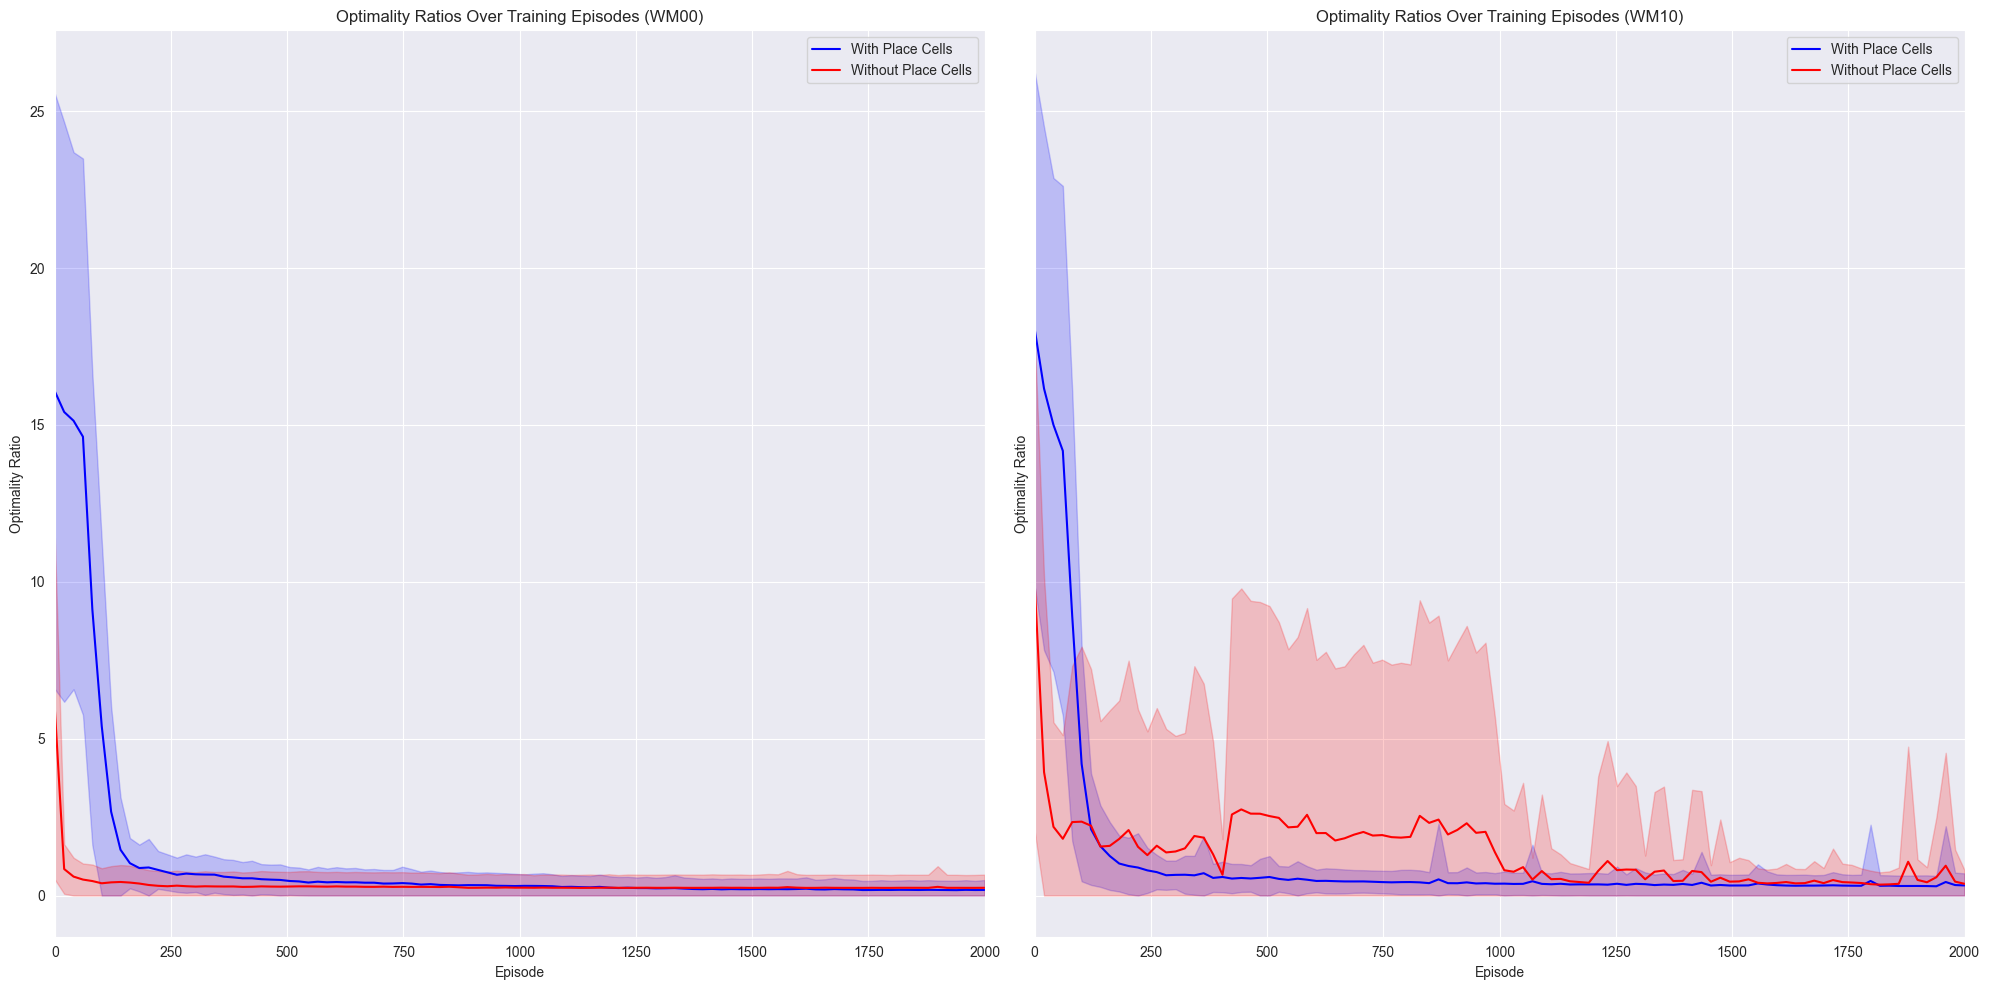

In [5]:
def plot_average_optimality_ratios(experiment_data_WM00_PC, experiment_data_WM10_PC, experiment_data_no_pc_WM00, experiment_data_no_pc_WM10):
    # Function to calculate the average optimality ratios and variance
    def calculate_average_and_variance_optimality_ratios(experiment_data):
        episode_count = len(experiment_data[0].optimality_ratio_history)
        average_optimality_ratios = np.zeros(episode_count)
        variance_optimality_ratios = np.zeros(episode_count)
        
        for logger in experiment_data:
            average_optimality_ratios += np.array(logger.optimality_ratio_history)
        
        average_optimality_ratios /= len(experiment_data)
        
        for logger in experiment_data:
            variance_optimality_ratios += (np.array(logger.optimality_ratio_history) - average_optimality_ratios) ** 2
        
        variance_optimality_ratios /= len(experiment_data)
        return average_optimality_ratios, variance_optimality_ratios
    
    # Function to reduce data points by averaging every n points
    def reduce_data_points(data, n=20):
        reduced_data = []
        for i in range(0, len(data), n):
            reduced_data.append(np.mean(data[i:i + n]))
        return reduced_data
    
    # Function to reduce variance data points by averaging every n points
    def reduce_variance_data_points(data, n=20):
        reduced_data = []
        for i in range(0, len(data), n):
            reduced_data.append(np.mean(data[i:i + n]))
        return reduced_data
    
    # Calculate the average optimality ratios and variances for each set of experiments
    avg_optimality_ratios_WM00_PC, var_optimality_ratios_WM00_PC = calculate_average_and_variance_optimality_ratios(experiment_data_WM00_PC)
    avg_optimality_ratios_WM10_PC, var_optimality_ratios_WM10_PC = calculate_average_and_variance_optimality_ratios(experiment_data_WM10_PC)
    avg_optimality_ratios_WM00_no_pc, var_optimality_ratios_WM00_no_pc = calculate_average_and_variance_optimality_ratios(experiment_data_no_pc_WM00)
    avg_optimality_ratios_WM10_no_pc, var_optimality_ratios_WM10_no_pc = calculate_average_and_variance_optimality_ratios(experiment_data_no_pc_WM10)

    # Reduce the data points to 100 by averaging every 20 points
    reduced_WM00_PC = reduce_data_points(avg_optimality_ratios_WM00_PC, n=20)
    reduced_WM10_PC = reduce_data_points(avg_optimality_ratios_WM10_PC, n=20)
    reduced_WM00_no_pc = reduce_data_points(avg_optimality_ratios_WM00_no_pc, n=20)
    reduced_WM10_no_pc = reduce_data_points(avg_optimality_ratios_WM10_no_pc, n=20)

    # Reduce the variance data points to 100 by averaging every 20 points
    reduced_var_WM00_PC = reduce_variance_data_points(var_optimality_ratios_WM00_PC, n=20)
    reduced_var_WM10_PC = reduce_variance_data_points(var_optimality_ratios_WM10_PC, n=20)
    reduced_var_WM00_no_pc = reduce_variance_data_points(var_optimality_ratios_WM00_no_pc, n=20)
    reduced_var_WM10_no_pc = reduce_variance_data_points(var_optimality_ratios_WM10_no_pc, n=20)

    # Create subplots
    fig, axes = plt.subplots(1, 2, figsize=(20, 10), sharey=True)

    # X-axis values to keep the scale from 0 to 2000
    x_values = np.linspace(0, 2000, num=len(reduced_WM00_PC))

    # Plot for WM00
    axes[0].plot(x_values, reduced_WM00_PC, label='With Place Cells', color='blue')
    axes[0].fill_between(x_values, np.clip(np.array(reduced_WM00_PC) - np.sqrt(reduced_var_WM00_PC), 0, None), np.array(reduced_WM00_PC) + np.sqrt(reduced_var_WM00_PC), color='blue', alpha=0.2)
    axes[0].plot(x_values, reduced_WM00_no_pc, label='Without Place Cells', color='red')
    axes[0].fill_between(x_values, np.clip(np.array(reduced_WM00_no_pc) - np.sqrt(reduced_var_WM00_no_pc), 0, None), np.array(reduced_WM00_no_pc) + np.sqrt(reduced_var_WM00_no_pc), color='red', alpha=0.2)
    axes[0].set_xlim(0, 2000)
    axes[0].set_title('Optimality Ratios Over Training Episodes (WM00)')
    axes[0].set_xlabel('Episode')
    axes[0].set_ylabel('Optimality Ratio')
    axes[0].legend()

    # Plot for WM10
    axes[1].plot(x_values, reduced_WM10_PC, label='With Place Cells', color='blue')
    axes[1].fill_between(x_values, np.clip(np.array(reduced_WM10_PC) - np.sqrt(reduced_var_WM10_PC), 0, None), np.array(reduced_WM10_PC) + np.sqrt(reduced_var_WM10_PC), color='blue', alpha=0.2)
    axes[1].plot(x_values, reduced_WM10_no_pc, label='Without Place Cells', color='red')
    axes[1].fill_between(x_values, np.clip(np.array(reduced_WM10_no_pc) - np.sqrt(reduced_var_WM10_no_pc), 0, None), np.array(reduced_WM10_no_pc) + np.sqrt(reduced_var_WM10_no_pc), color='red', alpha=0.2)
    axes[1].set_xlim(0, 2000)
    axes[1].set_title('Optimality Ratios Over Training Episodes (WM10)')
    axes[1].set_xlabel('Episode')
    axes[1].set_ylabel('Optimality Ratio')
    axes[1].legend()

    plt.tight_layout()
    plt.show()


plot_average_optimality_ratios(experiment_data_WM00_PC, experiment_data_WM10_PC, experiment_data_WM00_no_pc, experiment_data_WM10_no_pc)


In [6]:
def perform_levenes_test(data1, data2):
    stat, p_value = levene(data1, data2)
    return stat, p_value

variances_WM00_PC = get_variances(experiment_data_WM00_PC)
variances_WM10_PC = get_variances(experiment_data_WM10_PC)
variances_no_pc_WM00 = get_variances(experiment_data_WM00_no_pc)
variances_no_pc_WM10 = get_variances(experiment_data_WM10_no_pc)

# Perform Levene's Test
stat_WM00, p_value_WM00 = perform_levenes_test(variances_WM00_PC, variances_no_pc_WM00)
stat_WM10, p_value_WM10 = perform_levenes_test(variances_WM10_PC, variances_no_pc_WM10)

print(f"Levene's Test WM00: Statistic={stat_WM00}, P-value={p_value_WM00}")
print(f"Levene's Test WM10: Statistic={stat_WM10}, P-value={p_value_WM10}")

Levene's Test WM00: Statistic=6.678603340304865, P-value=0.01870624700856199
Levene's Test WM10: Statistic=1.510801944833611, P-value=0.23484342843682623


In [7]:
def calculate_mean_and_std(experiment_loggers):
    means = []
    stds = []
    for logger in experiment_loggers:
        means.append(np.mean(logger.optimality_ratio_history))
        stds.append(np.std(logger.optimality_ratio_history))
    overall_mean = np.mean(means)
    overall_std = np.mean(stds)
    return overall_mean, overall_std

def calculate_variance(experiment_loggers):
    variances = []
    for logger in experiment_loggers:
        variances.append(np.var(logger.optimality_ratio_history))
    overall_variance = np.mean(variances)
    return overall_variance


def plot_optimality_ratios(experiment_loggers, title="Optimality Ratios Over Time"):
    plt.figure(figsize=(12, 6))
    for logger in experiment_loggers:
        plt.plot(logger.optimality_ratio_history, alpha=0.3)
    plt.xlabel('Episode')
    plt.ylabel('Optimality Ratio')
    plt.title(title)
    plt.show()

def plot_smoothed_optimality_ratios(experiment_data_WM00_PC, experiment_data_WM10_PC, experiment_data_WM00_no_pc, experiment_data_WM10_no_pc, window_size=50):
    fig, axes = plt.subplots(2, 2, figsize=(20, 15),sharey=True)

    # Plot for WM00 with Place Cells
    for idx, logger in enumerate(experiment_data_WM00_PC):
        smoothed_ratios = np.convolve(logger.optimality_ratio_history, np.ones(window_size)/window_size, mode='valid')
        axes[0, 0].plot(smoothed_ratios, label=f'Model {idx + 1}')
    axes[0, 0].set_title('Smoothed Optimality Ratios (With PC, WM00)')
    axes[0, 0].set_xlabel('Episode')
    axes[0, 0].set_ylabel('Optimality Ratio')
    axes[0, 0].legend()

    # Plot for WM10 with Place Cells
    for idx, logger in enumerate(experiment_data_WM10_PC):
        smoothed_ratios = np.convolve(logger.optimality_ratio_history, np.ones(window_size)/window_size, mode='valid')
        axes[0, 1].plot(smoothed_ratios, label=f'Model {idx + 1}')
    axes[1, 0].set_title('Smoothed Optimality Ratios (With PC, WM10)')
    axes[1, 0].set_xlabel('Episode')
    axes[1, 0].set_ylabel('Optimality Ratio')
    axes[1, 0].legend()

    # Plot for WM00 without Place Cells
    for idx, logger in enumerate(experiment_data_WM00_no_pc):
        smoothed_ratios = np.convolve(logger.optimality_ratio_history, np.ones(window_size)/window_size, mode='valid')
        axes[1, 0].plot(smoothed_ratios, label=f'Model {idx + 1}')
    axes[0, 1].set_title('Smoothed Optimality Ratios (No PC, WM00)')
    axes[0, 1].set_xlabel('Episode')
    axes[0, 1].set_ylabel('Optimality Ratio')
    axes[0, 1].legend()

    # Plot for WM10 without Place Cells
    for idx, logger in enumerate(experiment_data_WM10_no_pc):
        smoothed_ratios = np.convolve(logger.optimality_ratio_history, np.ones(window_size)/window_size, mode='valid')
        axes[1, 1].plot(smoothed_ratios, label=f'Model {idx + 1}')
    axes[1, 1].set_title('Smoothed Optimality Ratios (No PC, WM10)')
    axes[1, 1].set_xlabel('Episode')
    axes[1, 1].set_ylabel('Optimality Ratio')
    axes[1, 1].legend()

    plt.tight_layout()
    plt.show()


def perform_levenes_test(loggers1, loggers2):
    means1 = [np.mean(logger.optimality_ratio_history) for logger in loggers1]
    means2 = [np.mean(logger.optimality_ratio_history) for logger in loggers2]
    stat, p_value = levene(means1, means2)
    return stat, p_value

def convergence_point(experiment_loggers, threshold=0.1):
    convergence_points = []
    for logger in experiment_loggers:
        for i in range(1, len(logger.optimality_ratio_history)):
            if abs(logger.optimality_ratio_history[i] - logger.optimality_ratio_history[i-1]) < threshold:
                convergence_points.append(i)
                break
    return np.mean(convergence_points) if convergence_points else len(logger.optimality_ratio_history)


def residual_analysis(experiment_loggers_pc_wm00, experiment_loggers_pc_wm10, experiment_loggers_no_pc_wm00, experiment_loggers_no_pc_wm10, window_size=50):
    num_loggers = len(experiment_loggers_pc_wm00)
    fig, axes = plt.subplots(num_loggers, 4, figsize=(20, 5 * num_loggers),sharey=True)

    for idx in range(num_loggers):
        # With Place Cells, WM00
        logger = experiment_loggers_pc_wm00[idx]
        moving_avg = np.convolve(logger.optimality_ratio_history, np.ones(window_size) / window_size, mode='valid')
        residuals = logger.optimality_ratio_history[window_size - 1:] - moving_avg
        axes[idx, 0].plot(residuals, label=f'Residuals Model {idx + 1}')
        axes[idx, 0].set_xlabel('Episode')
        axes[idx, 0].set_ylabel('Residual')
        axes[idx, 0].set_title(f'Residuals (Model {idx + 1}, With PC, WM00)')
        axes[idx, 0].legend()
        stat, p_value = normaltest(residuals)
        print(f"Normality Test for Model {idx + 1} (With PC, WM00): {stat}, P-value: {p_value}")

        # With Place Cells, WM10
        logger = experiment_loggers_pc_wm10[idx]
        moving_avg = np.convolve(logger.optimality_ratio_history, np.ones(window_size) / window_size, mode='valid')
        residuals = logger.optimality_ratio_history[window_size - 1:] - moving_avg
        axes[idx, 2].plot(residuals, label=f'Residuals Model {idx + 1}')
        axes[idx, 2].set_xlabel('Episode')
        axes[idx, 2].set_ylabel('Residual')
        axes[idx, 2].set_title(f'Residuals (Model {idx + 1}, With PC, WM10)')
        axes[idx, 2].legend()
        stat, p_value = normaltest(residuals)
        print(f"Normality Test for Model {idx + 1} (With PC, WM10): {stat}, P-value: {p_value}")

        # Without Place Cells, WM00
        logger = experiment_loggers_no_pc_wm00[idx]
        moving_avg = np.convolve(logger.optimality_ratio_history, np.ones(window_size) / window_size, mode='valid')
        residuals = logger.optimality_ratio_history[window_size - 1:] - moving_avg
        axes[idx, 1].plot(residuals, label=f'Residuals Model {idx + 1}')
        axes[idx, 1].set_xlabel('Episode')
        axes[idx, 1].set_ylabel('Residual')
        axes[idx, 1].set_title(f'Residuals (Model {idx + 1}, No PC, WM00)')
        axes[idx, 1].legend()
        stat, p_value = normaltest(residuals)
        print(f"Normality Test for Model {idx + 1} (No PC, WM00): {stat}, P-value: {p_value}")

        # Without Place Cells, WM10
        logger = experiment_loggers_no_pc_wm10[idx]
        moving_avg = np.convolve(logger.optimality_ratio_history, np.ones(window_size) / window_size, mode='valid')
        residuals = logger.optimality_ratio_history[window_size - 1:] - moving_avg
        axes[idx, 3].plot(residuals, label=f'Residuals Model {idx + 1}')
        axes[idx, 3].set_xlabel('Episode')
        axes[idx, 3].set_ylabel('Residual')
        axes[idx, 3].set_title(f'Residuals (Model {idx + 1}, No PC, WM10)')
        axes[idx, 3].legend()
        stat, p_value = normaltest(residuals)
        print(f"Normality Test for Model {idx + 1} (No PC, WM10): {stat}, P-value: {p_value}")

    plt.tight_layout()
    plt.show()
    
def plot_and_analyze_rolling_statistics(experiment_data_WM00_PC, experiment_data_WM10_PC, experiment_data_WM00_no_pc, experiment_data_WM10_no_pc, window_size=50):
    """
    Generates rolling statistics (mean and standard deviation) for optimality ratios of RL models in a single plot with subplots,
    and performs statistical analysis on the rolling statistics.

    Parameters:
    experiment_data_WM00_PC (list): List of ExperimentLogger objects for WM00 with place cells.
    experiment_data_WM10_PC (list): List of ExperimentLogger objects for WM10 with place cells.
    experiment_data_WM00_no_pc (list): List of ExperimentLogger objects for WM00 without place cells.
    experiment_data_WM10_no_pc (list): List of ExperimentLogger objects for WM10 without place cells.
    window_size (int): The size of the rolling window.
    """
    fig, axs = plt.subplots(10, 4, figsize=(20, 50))
    
    data_sets = [
        (experiment_data_WM00_PC, 'WM00_PC'),
        (experiment_data_WM10_PC, 'WM10_PC'),
        (experiment_data_WM00_no_pc, 'WM00_no_pc'),
        (experiment_data_WM10_no_pc, 'WM10_no_pc')
    ]
    
    rolling_means = {key: [] for key in ['WM00_PC', 'WM10_PC', 'WM00_no_pc', 'WM10_no_pc']}
    rolling_stds = {key: [] for key in ['WM00_PC', 'WM10_PC', 'WM00_no_pc', 'WM10_no_pc']}
    
    for col, (experiment_data, title_suffix) in enumerate(data_sets):
        for idx, logger in enumerate(experiment_data):
            optimality_ratios = pd.Series(logger.optimality_ratio_history)
            rolling_mean = optimality_ratios.rolling(window=window_size).mean()
            rolling_std = optimality_ratios.rolling(window=window_size).std()
            
            rolling_means[title_suffix].append(rolling_mean.mean())
            rolling_stds[title_suffix].append(rolling_std.mean())
            
            axs[idx, col].plot(optimality_ratios, color='blue', label='Original')
            axs[idx, col].plot(rolling_mean, color='red', label='Rolling Mean')
            axs[idx, col].plot(rolling_std, color='black', label='Rolling Std')
            axs[idx, col].set_title(f'Rolling Statistics (Model {idx + 1}, {title_suffix})')
            axs[idx, col].set_xlabel('Episode')
            axs[idx, col].set_ylabel('Optimality Ratio')
            axs[idx, col].legend()
    
    plt.tight_layout()
    plt.show()
    
    # Statistical Analysis
    for key1, key2 in [('WM00_PC', 'WM00_no_pc'), ('WM10_PC', 'WM10_no_pc')]:
        print(f'Statistical analysis between {key1} and {key2}')
        
        # T-test for rolling means
        t_stat_mean, p_value_mean = ttest_ind(rolling_means[key1], rolling_means[key2])
        print(f'T-test for rolling means: t-statistic = {t_stat_mean}, p-value = {p_value_mean}')
        
        # T-test for rolling stds
        t_stat_std, p_value_std = ttest_ind(rolling_stds[key1], rolling_stds[key2])
        print(f'T-test for rolling standard deviations: t-statistic = {t_stat_std}, p-value = {p_value_std}')



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


WM00 (With PC): Mean=1.1170149999999999, Std=3.799519396260183
WM10 (With PC): Mean=1.210015, Std=3.7371453642544674
WM00 (Without PC): Mean=0.340685, Std=1.0833152008793374
WM10 (Without PC): Mean=1.3694736363636362, Std=3.2088402284487154
WM00 (With PC): Variance=14.480486618250001
WM10 (With PC): Variance=13.99845891491529
WM00 (Without PC): Variance=1.21393853325
WM10 (Without PC): Variance=16.778647749421488


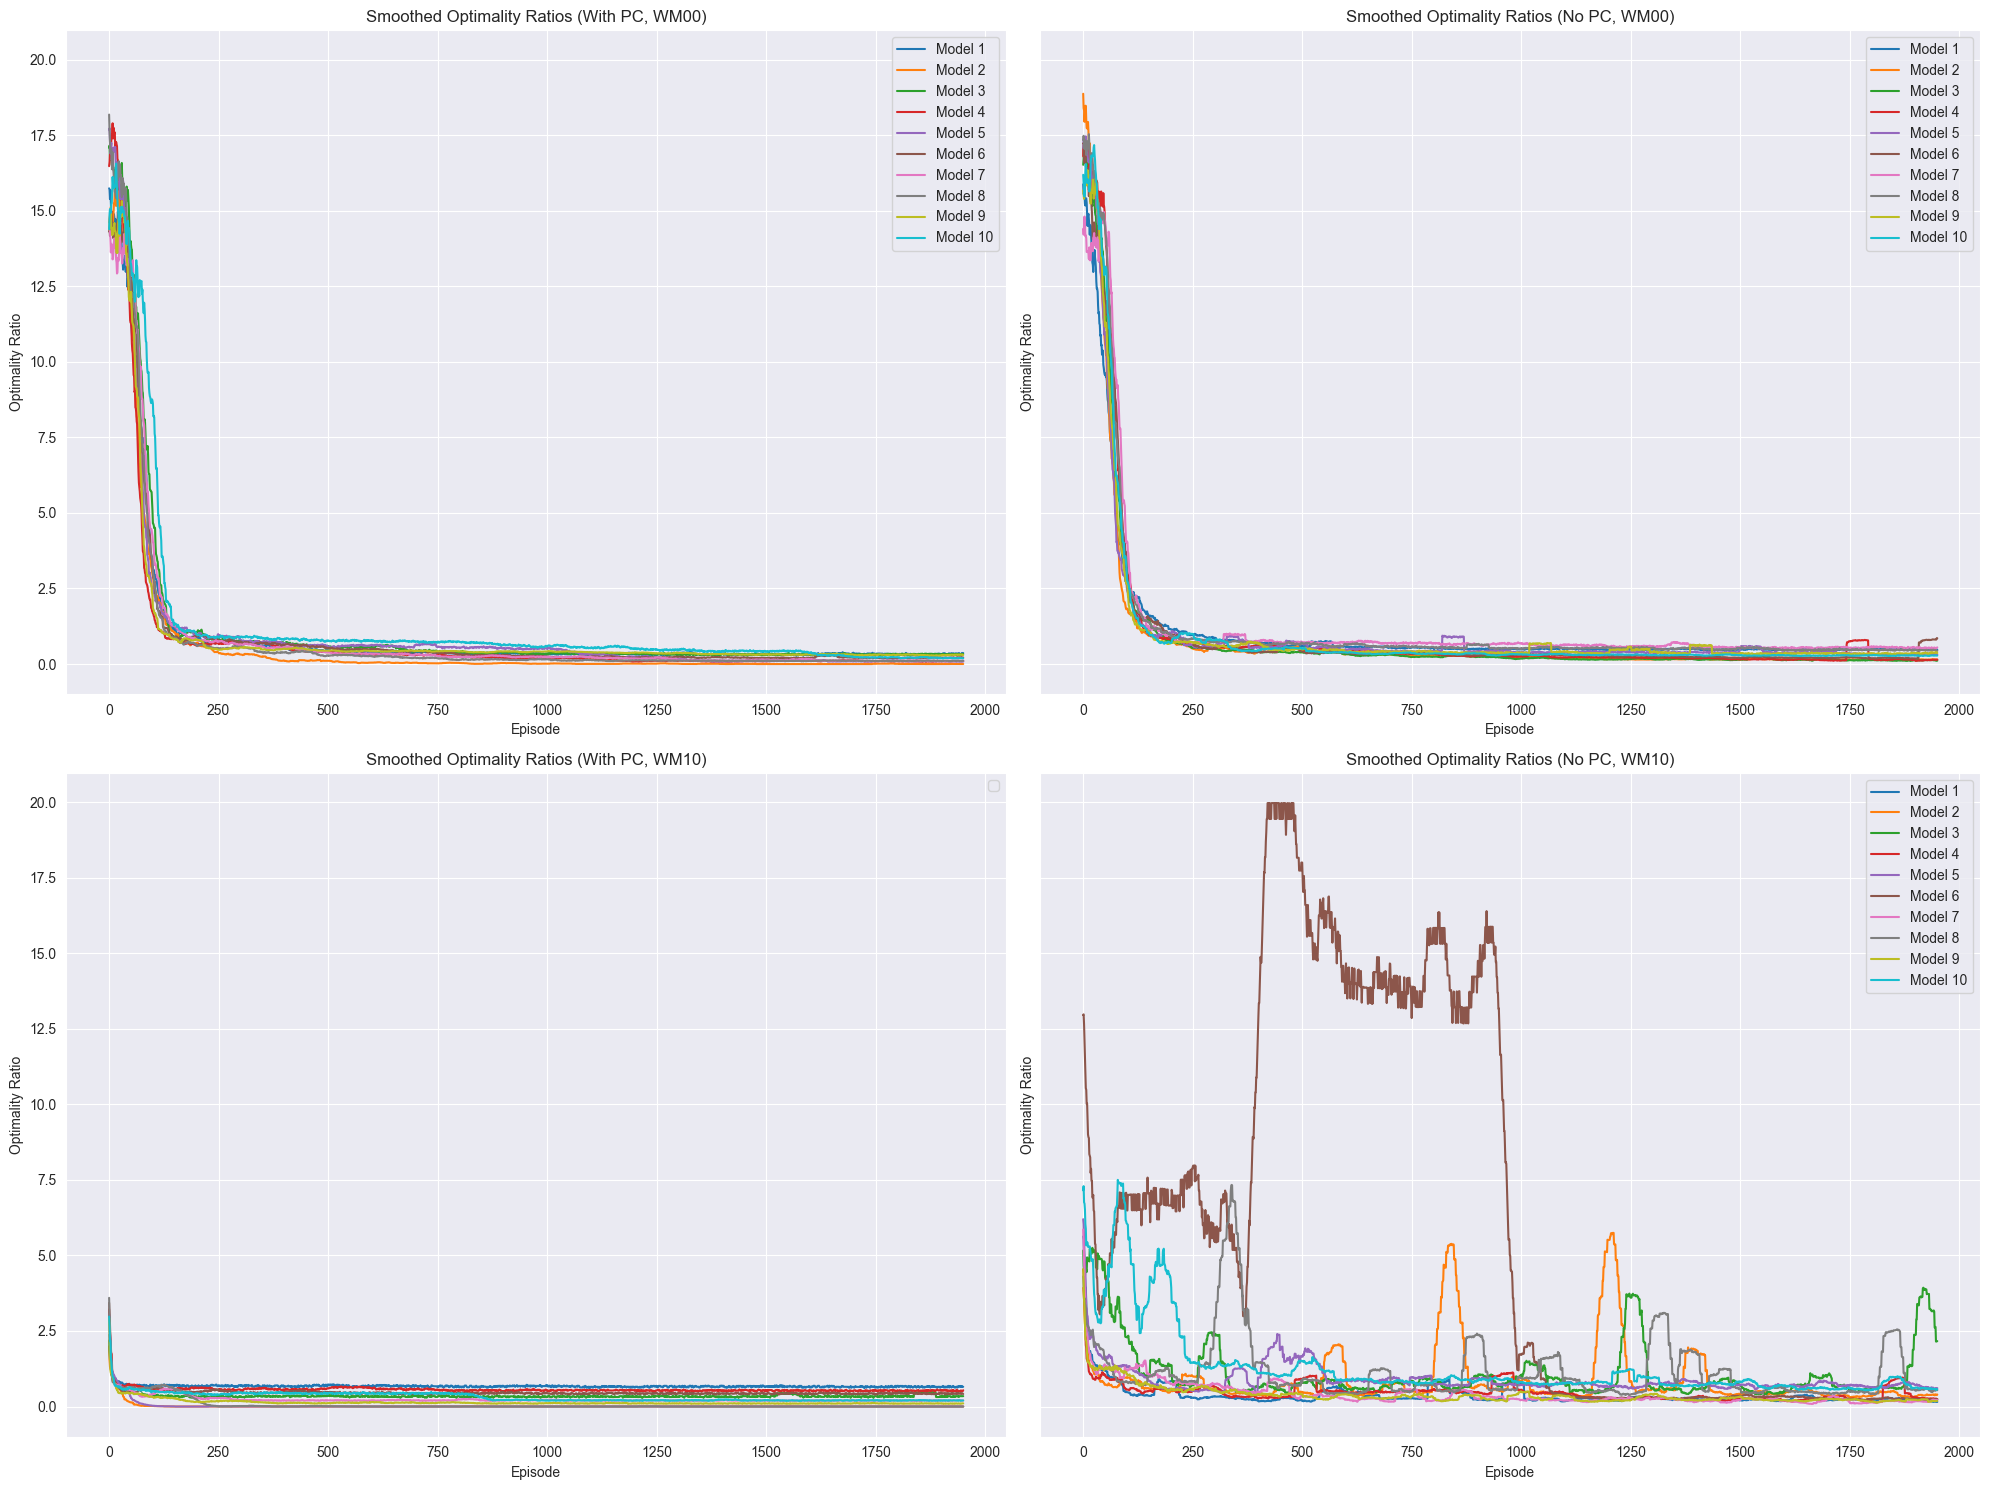

Levene's Test (WM00): Statistic=1.36355805343676, P-value=0.25815736142843587
Levene's Test (WM10): Statistic=2.043455835378171, P-value=0.16998912503821545
Convergence Point (WM00, PC): 12.2
Convergence Point (WM10, PC): 11.3
Convergence Point (WM00, No PC): 16.2
Convergence Point (WM10, No PC): 22.3


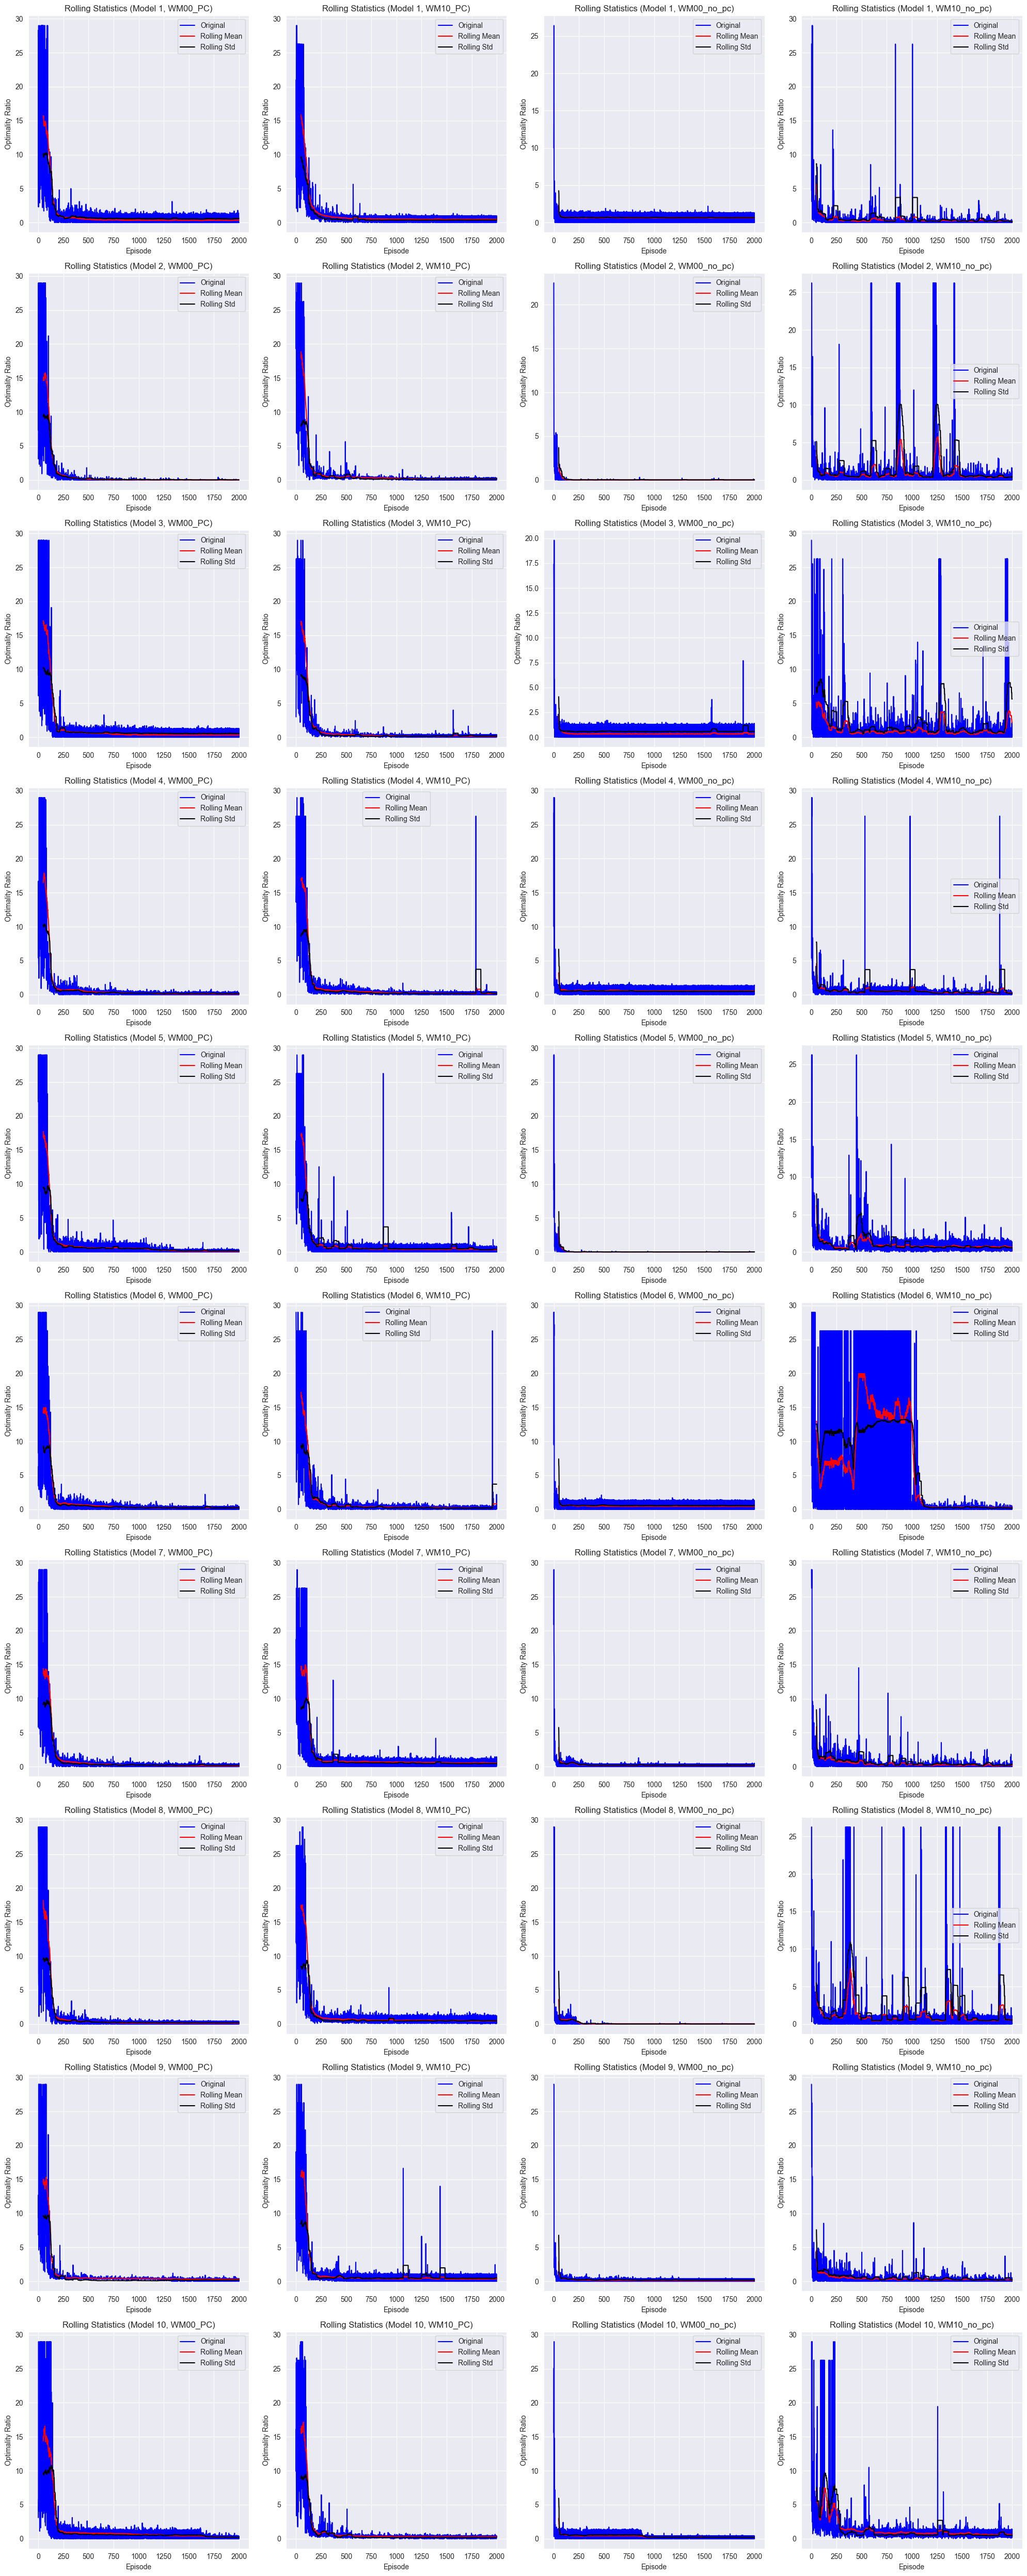

Statistical analysis between WM00_PC and WM00_no_pc
T-test for rolling means: t-statistic = 7.144755326719298, p-value = 1.1792484261712423e-06
T-test for rolling standard deviations: t-statistic = 4.424006391384939, p-value = 0.00032760501335530527
Statistical analysis between WM10_PC and WM10_no_pc
T-test for rolling means: t-statistic = -0.5140529952512531, p-value = 0.6134681713646349
T-test for rolling standard deviations: t-statistic = -1.669870821461403, p-value = 0.11224275351199292


In [8]:
# Calculate mean and standard deviation
mean_ratio_WM00_PC, std_ratio_WM00_PC = calculate_mean_and_std(experiment_data_WM00_PC)
mean_ratio_WM10_PC, std_ratio_WM10_PC = calculate_mean_and_std(experiment_data_WM10_PC)
mean_ratio_WM00_no_pc, std_ratio_WM00_no_pc = calculate_mean_and_std(experiment_data_WM00_no_pc)
mean_ratio_WM10_no_pc, std_ratio_WM10_no_pc = calculate_mean_and_std(experiment_data_WM10_no_pc)

print(f"WM00 (With PC): Mean={mean_ratio_WM00_PC}, Std={std_ratio_WM00_PC}")
print(f"WM10 (With PC): Mean={mean_ratio_WM10_PC}, Std={std_ratio_WM10_PC}")
print(f"WM00 (Without PC): Mean={mean_ratio_WM00_no_pc}, Std={std_ratio_WM00_no_pc}")
print(f"WM10 (Without PC): Mean={mean_ratio_WM10_no_pc}, Std={std_ratio_WM10_no_pc}")

# Calculate variance
variance_WM00_PC = calculate_variance(experiment_data_WM00_PC)
variance_WM10_PC = calculate_variance(experiment_data_WM10_PC)
variance_WM00_no_pc = calculate_variance(experiment_data_WM00_no_pc)
variance_WM10_no_pc = calculate_variance(experiment_data_WM10_no_pc)

print(f"WM00 (With PC): Variance={variance_WM00_PC}")
print(f"WM10 (With PC): Variance={variance_WM10_PC}")
print(f"WM00 (Without PC): Variance={variance_WM00_no_pc}")
print(f"WM10 (Without PC): Variance={variance_WM10_no_pc}")

# # Plot trend analysis
# plot_optimality_ratios(experiment_data_WM00_PC, "Optimality Ratios Over Time (WM00, PC)")
# plot_optimality_ratios(experiment_data_WM10_PC, "Optimality Ratios Over Time (WM10, PC)")
# plot_optimality_ratios(experiment_data_WM00_no_pc, "Optimality Ratios Over Time (WM00, No PC)")
# plot_optimality_ratios(experiment_data_WM10_no_pc, "Optimality Ratios Over Time (WM10, No PC)")

# Plot smoothed optimality ratios
plot_smoothed_optimality_ratios(experiment_data_WM00_PC, experiment_data_WM10_PC, experiment_data_WM00_no_pc, experiment_data_WM10_no_pc)

# Perform Levene's test
stat_WM00, p_value_WM00 = perform_levenes_test(experiment_data_WM00_PC, experiment_data_WM00_no_pc)
stat_WM10, p_value_WM10 = perform_levenes_test(experiment_data_WM10_PC, experiment_data_WM10_no_pc)
print(f"Levene's Test (WM00): Statistic={stat_WM00}, P-value={p_value_WM00}")
print(f"Levene's Test (WM10): Statistic={stat_WM10}, P-value={p_value_WM10}")

# Convergence analysis
conv_point_WM00_PC = convergence_point(experiment_data_WM00_PC)
conv_point_WM10_PC = convergence_point(experiment_data_WM10_PC)
conv_point_WM00_no_pc = convergence_point(experiment_data_WM00_no_pc)
conv_point_WM10_no_pc = convergence_point(experiment_data_WM10_no_pc)
print(f"Convergence Point (WM00, PC): {conv_point_WM00_PC}")
print(f"Convergence Point (WM10, PC): {conv_point_WM10_PC}")
print(f"Convergence Point (WM00, No PC): {conv_point_WM00_no_pc}")
print(f"Convergence Point (WM10, No PC): {conv_point_WM10_no_pc}")

# Residual analysis
plot_and_analyze_rolling_statistics(experiment_data_WM00_PC, experiment_data_WM10_PC, experiment_data_WM00_no_pc, experiment_data_WM10_no_pc, window_size=50)


In [9]:
def calculate_mean_and_std(experiment_loggers):
    means = [np.mean(logger.optimality_ratio_history) for logger in experiment_loggers]
    stds = [np.std(logger.optimality_ratio_history) for logger in experiment_loggers]
    return np.mean(means), np.mean(stds)

def calculate_variance(experiment_loggers):
    variances = [np.var(logger.optimality_ratio_history) for logger in experiment_loggers]
    return np.mean(variances)

def convergence_point(experiment_loggers, threshold=0.1):
    convergence_points = []
    for logger in experiment_loggers:
        for i in range(1, len(logger.optimality_ratio_history)):
            if abs(logger.optimality_ratio_history[i] - logger.optimality_ratio_history[i-1]) < threshold:
                convergence_points.append(i)
                break
    return np.mean(convergence_points) if convergence_points else len(logger.optimality_ratio_history)

def perform_statistical_tests(data1, data2):
    # T-test
    t_stat, t_p_value = ttest_ind(
        [np.mean(logger.optimality_ratio_history) for logger in data1],
        [np.mean(logger.optimality_ratio_history) for logger in data2]
    )

    # Wilcoxon Signed-Rank Test
    wilcoxon_stat, wilcoxon_p_value = wilcoxon(
        [np.mean(logger.optimality_ratio_history) for logger in data1],
        [np.mean(logger.optimality_ratio_history) for logger in data2]
    )

    # Levene's Test
    levene_stat, levene_p_value = levene(
        [np.mean(logger.optimality_ratio_history) for logger in data1],
        [np.mean(logger.optimality_ratio_history) for logger in data2]
    )

    return {
        't_stat': t_stat, 't_p_value': t_p_value,
        'wilcoxon_stat': wilcoxon_stat, 'wilcoxon_p_value': wilcoxon_p_value,
        'levene_stat': levene_stat, 'levene_p_value': levene_p_value
    }


In [10]:
# Calculate metrics
mean_WM00_PC, std_WM00_PC = calculate_mean_and_std(experiment_data_WM00_PC)
mean_WM10_PC, std_WM10_PC = calculate_mean_and_std(experiment_data_WM10_PC)
mean_WM00_no_pc, std_WM00_no_pc = calculate_mean_and_std(experiment_data_WM00_no_pc)
mean_WM10_no_pc, std_WM10_no_pc = calculate_mean_and_std(experiment_data_WM10_no_pc)

variance_WM00_PC = calculate_variance(experiment_data_WM00_PC)
variance_WM10_PC = calculate_variance(experiment_data_WM10_PC)
variance_WM00_no_pc = calculate_variance(experiment_data_WM00_no_pc)
variance_WM10_no_pc = calculate_variance(experiment_data_WM10_no_pc)

conv_point_WM00_PC = convergence_point(experiment_data_WM00_PC, threshold=0.05)
conv_point_WM10_PC = convergence_point(experiment_data_WM10_PC, threshold=0.05)
conv_point_WM00_no_pc = convergence_point(experiment_data_WM00_no_pc, threshold=0.05)
conv_point_WM10_no_pc = convergence_point(experiment_data_WM10_no_pc, threshold=0.05)

# Perform statistical tests
stats_WM00 = perform_statistical_tests(experiment_data_WM00_PC, experiment_data_WM00_no_pc)
stats_WM10 = perform_statistical_tests(experiment_data_WM10_PC, experiment_data_WM10_no_pc)

# Summary of Results
print("Summary of Results:")
print(f"WM00 (With PC): Mean={mean_WM00_PC}, Std={std_WM00_PC}, Variance={variance_WM00_PC}, Convergence Point={conv_point_WM00_PC}")
print(f"WM10 (With PC): Mean={mean_WM10_PC}, Std={std_WM10_PC}, Variance={variance_WM10_PC}, Convergence Point={conv_point_WM10_PC}")
print(f"WM00 (Without PC): Mean={mean_WM00_no_pc}, Std={std_WM00_no_pc}, Variance={variance_WM00_no_pc}, Convergence Point={conv_point_WM00_no_pc}")
print(f"WM10 (Without PC): Mean={mean_WM10_no_pc}, Std={std_WM10_no_pc}, Variance={variance_WM10_no_pc}, Convergence Point={conv_point_WM10_no_pc}")

print(f"T-Test WM00: Statistic={stats_WM00['t_stat']}, P-value={stats_WM00['t_p_value']}")
print(f"T-Test WM10: Statistic={stats_WM10['t_stat']}, P-value={stats_WM10['t_p_value']}")
print(f"Wilcoxon Test WM00: Statistic={stats_WM00['wilcoxon_stat']}, P-value={stats_WM00['wilcoxon_p_value']}")
print(f"Wilcoxon Test WM10: Statistic={stats_WM10['wilcoxon_stat']}, P-value={stats_WM10['wilcoxon_p_value']}")
print(f"Levene's Test WM00: Statistic={stats_WM00['levene_stat']}, P-value={stats_WM00['levene_p_value']}")
print(f"Levene's Test WM10: Statistic={stats_WM10['levene_stat']}, P-value={stats_WM10['levene_p_value']}")

Summary of Results:
WM00 (With PC): Mean=1.1170149999999999, Std=3.799519396260183, Variance=14.480486618250001, Convergence Point=14.3
WM10 (With PC): Mean=1.210015, Std=3.7371453642544674, Variance=13.99845891491529, Convergence Point=11.3
WM00 (Without PC): Mean=0.340685, Std=1.0833152008793374, Variance=1.21393853325, Convergence Point=20.6
WM10 (Without PC): Mean=1.3694736363636362, Std=3.2088402284487154, Variance=16.778647749421488, Convergence Point=22.4
T-Test WM00: Statistic=8.581794215438649, P-value=8.891337916145067e-08
T-Test WM10: Statistic=-0.30073960270873545, P-value=0.7670591359081624
Wilcoxon Test WM00: Statistic=0.0, P-value=0.001953125
Wilcoxon Test WM10: Statistic=15.0, P-value=0.232421875
Levene's Test WM00: Statistic=1.36355805343676, P-value=0.25815736142843587
Levene's Test WM10: Statistic=2.043455835378171, P-value=0.16998912503821545


In [28]:
def extract_final_optimality_ratios(experiment_loggers):
    """
    Extracts the final 100 optimality ratios from the given list of ExperimentLogger objects.
    
    Parameters:
    experiment_loggers (list): List of ExperimentLogger objects.
    
    Returns:
    list: List of final 100 optimality ratios for each logger.
    """
    final_ratios = [logger.optimality_ratio_history[-250:] for logger in experiment_loggers]
    print(np.mean(final_ratios))
    return final_ratios

final_ratios_WM00_PC = extract_final_optimality_ratios(experiment_data_WM00_PC)
final_ratios_WM10_PC = extract_final_optimality_ratios(experiment_data_WM10_PC)
final_ratios_WM00_no_pc = extract_final_optimality_ratios(experiment_data_WM00_no_pc)
final_ratios_WM10_no_pc = extract_final_optimality_ratios(experiment_data_WM10_no_pc)

0.17751999999999998
0.3320618181818181
0.24736
0.5097527272727272


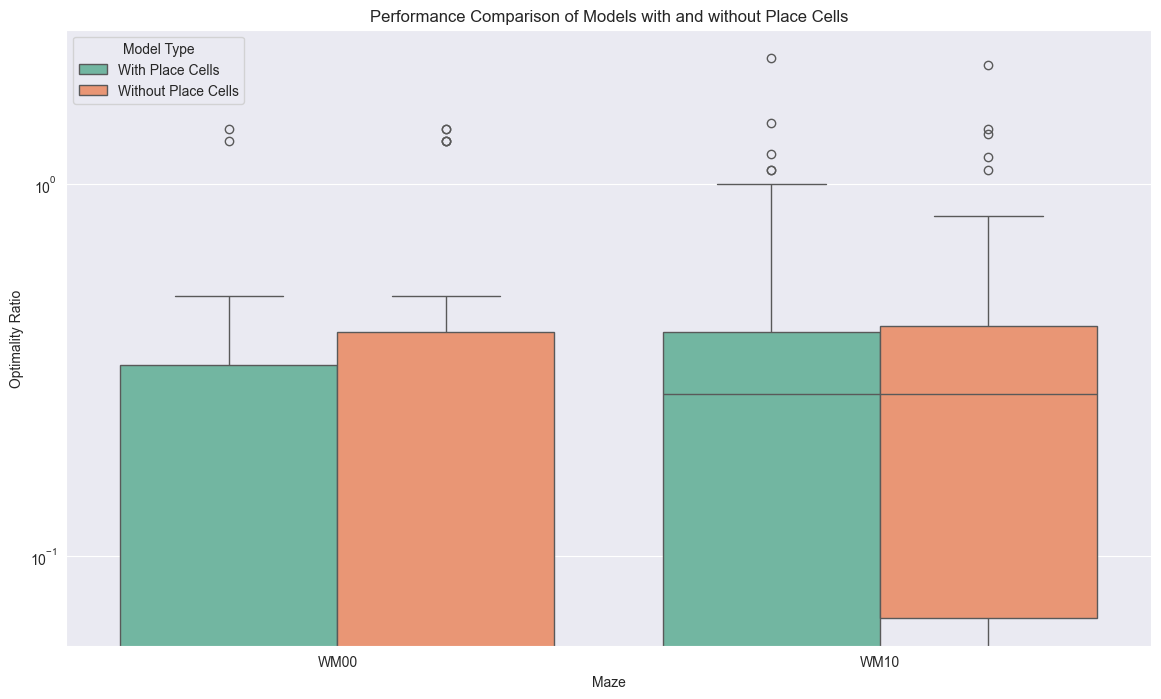

In [18]:
def plot_final_optimality_ratios_grouped_seaborn(final_ratios_WM00_PC, final_ratios_WM10_PC, final_ratios_WM00_no_pc, final_ratios_WM10_no_pc):
    """
    Plots the final optimality ratios of the last 100 training episodes as box plots,
    grouped by world configuration and model type, without showing outliers using seaborn.
    
    Parameters:
    final_ratios_WM00_PC (list): Final optimality ratios for WM00 with place cells.
    final_ratios_WM10_PC (list): Final optimality ratios for WM10 with place cells.
    final_ratios_WM00_no_pc (list): Final optimality ratios for WM00 without place cells.
    final_ratios_WM10_no_pc (list): Final optimality ratios for WM10 without place cells.
    """
    # Flatten the lists of final ratios
    final_ratios_WM00_PC = np.concatenate(final_ratios_WM00_PC).flatten()
    final_ratios_WM10_PC = np.concatenate(final_ratios_WM10_PC).flatten()
    final_ratios_WM00_no_pc = np.concatenate(final_ratios_WM00_no_pc).flatten()
    final_ratios_WM10_no_pc = np.concatenate(final_ratios_WM10_no_pc).flatten()

    data = {
        'Optimality Ratio': np.concatenate([
            final_ratios_WM00_PC, final_ratios_WM00_no_pc,
            final_ratios_WM10_PC, final_ratios_WM10_no_pc
        ]),
        'Model Type': ['With Place Cells'] * len(final_ratios_WM00_PC) +
                      ['Without Place Cells'] * len(final_ratios_WM00_no_pc) +
                      ['With Place Cells'] * len(final_ratios_WM10_PC) +
                      ['Without Place Cells'] * len(final_ratios_WM10_no_pc),
        'Maze': ['WM00'] * (len(final_ratios_WM00_PC) + len(final_ratios_WM00_no_pc)) +
                ['WM10'] * (len(final_ratios_WM10_PC) + len(final_ratios_WM10_no_pc))
    }

    df = pd.DataFrame(data)
    plt.figure(figsize=(14, 8))
    ax = sns.boxplot(x='Maze', y='Optimality Ratio', hue='Model Type', data=df, palette='Set2')

    plt.title('Performance Comparison of Models with and without Place Cells')
    plt.ylabel('Optimality Ratio')
    plt.xlabel('Maze')
    plt.yscale('log')
    plt.legend(title='Model Type')
    plt.show()

# Plot the final optimality ratios grouped by world configuration and model type using seaborn
plot_final_optimality_ratios_grouped_seaborn(final_ratios_WM00_PC, final_ratios_WM10_PC, final_ratios_WM00_no_pc, final_ratios_WM10_no_pc)


In [30]:
def perform_statistical_tests(final_ratios_WM00_PC, final_ratios_WM10_PC, final_ratios_WM00_no_pc, final_ratios_WM10_no_pc):
    """
    Performs statistical tests on the final optimality ratios to determine the best performing model.
    
    Parameters:
    final_ratios_WM00_PC (list): Final optimality ratios for WM00 with place cells.
    final_ratios_WM10_PC (list): Final optimality ratios for WM10 with place cells.
    final_ratios_WM00_no_pc (list): Final optimality ratios for WM00 without place cells.
    final_ratios_WM10_no_pc (list): Final optimality ratios for WM10 without place cells.
    """
    data_WM00_PC = np.concatenate(final_ratios_WM00_PC)
    data_WM10_PC = np.concatenate(final_ratios_WM10_PC)
    data_WM00_no_pc = np.concatenate(final_ratios_WM00_no_pc)
    data_WM10_no_pc = np.concatenate(final_ratios_WM10_no_pc)

    print('T-Test WM00:')
    t_stat, p_value = ttest_ind(data_WM00_PC, data_WM00_no_pc)
    print(f'T-statistic: {t_stat}, P-value: {p_value}')

    print('Wilcoxon Test WM00:')
    stat, p_value = wilcoxon(data_WM00_PC, data_WM00_no_pc)
    print(f'Statistic: {stat}, P-value: {p_value}')

    print('T-Test WM10:')
    t_stat, p_value = ttest_ind(data_WM10_PC, data_WM10_no_pc)
    print(f'T-statistic: {t_stat}, P-value: {p_value}')

    print('Wilcoxon Test WM10:')
    stat, p_value = wilcoxon(data_WM10_PC, data_WM10_no_pc)
    print(f'Statistic: {stat}, P-value: {p_value}')

# Perform statistical tests
perform_statistical_tests(final_ratios_WM00_PC, final_ratios_WM10_PC, final_ratios_WM00_no_pc, final_ratios_WM10_no_pc)


T-Test WM00:
T-statistic: -6.283836790040084, P-value: 3.583570672780478e-10
Wilcoxon Test WM00:
Statistic: 309401.5, P-value: 1.313907510560818e-07
T-Test WM10:
T-statistic: -4.679459728334178, P-value: 2.9522719077114386e-06
Wilcoxon Test WM10:
Statistic: 1020159.0, P-value: 1.724495481427812e-08
